In [25]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [26]:
files = [
    "cleaned_hampel.xlsx",
    "cleaned_reversal.xlsx",
    "cleaned_rolling.xlsx"
]

results = []

Dataset: cleaned_hampel.xlsx
MAE  : 393.08
RMSE : 709.65
R²   : 0.7881


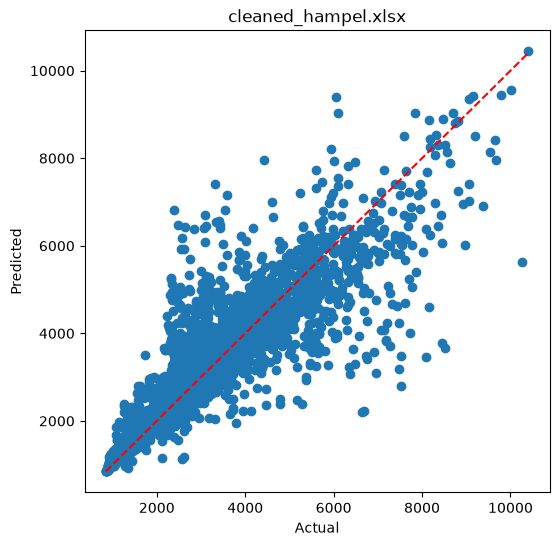


Feature Importance
    Feature  Importance
1  Daporizo    0.787178
0     Tamen    0.212822
Dataset: cleaned_reversal.xlsx
MAE  : 395.89
RMSE : 706.99
R²   : 0.7898


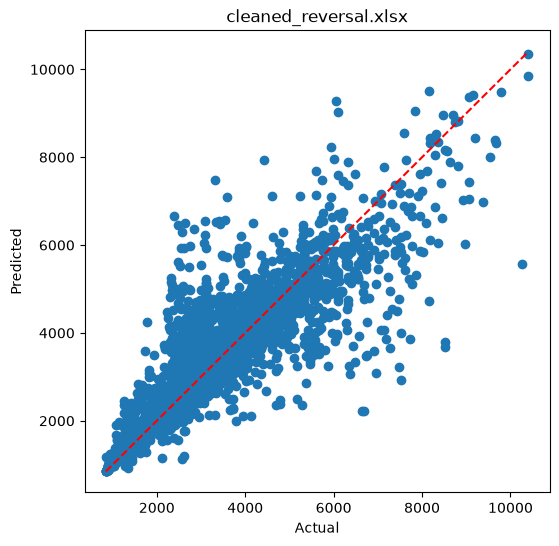


Feature Importance
    Feature  Importance
1  Daporizo    0.789415
0     Tamen    0.210585
Dataset: cleaned_rolling.xlsx
MAE  : 365.82
RMSE : 650.00
R²   : 0.8161


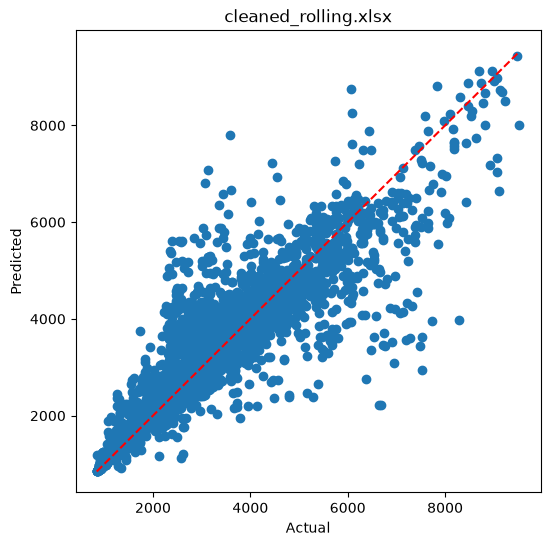


Feature Importance
    Feature  Importance
1  Daporizo    0.809671
0     Tamen    0.190329


In [27]:
for file in files:

    print("=" * 60)
    print("Dataset:", file)

    df = pd.read_excel(file)

    # Features and Target
    X = df[["Tamen", "Daporizo"]]
    y = df["Gerukamukh"]

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    # Model
    model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)
    # Train
    model.fit(X_train, y_train)

    # Predict
    predictions = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = mean_squared_error(y_test, predictions) ** 0.5
    r2 = r2_score(y_test, predictions)

    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")

    results.append({
        "Dataset": file,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    # Plot
    plt.figure(figsize=(6,6))

    plt.scatter(y_test, predictions)

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--'
    )

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(file)

    plt.show()

    # Feature Importance
    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": model.feature_importances_
    })

    print("\nFeature Importance")
    print(importance.sort_values(
        by="Importance",
        ascending=False
    ))

In [28]:
comparison = pd.DataFrame(results)

print("\nOverall Comparison")

comparison


Overall Comparison


,Dataset,MAE,RMSE,R2
0,cleaned_hampel.xlsx,393.081672,709.654978,0.788126
1,cleaned_reversal.xlsx,395.892466,706.986388,0.789844
2,cleaned_rolling.xlsx,365.818106,650.003693,0.816101
